<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Validation Legacy 3: Earth Precision
---

This notebook validates Earth matter propagation against legacy Peanuts. It compares the TPeanuts analytical and numerical propagation methods internally, and then validates the analytical result against legacy Peanuts `Pearth` over a grid of nadir angles, energies, and mass-basis inputs.

## Table of Contents

| Section | Title |
|---|-------|
| [0](#0.-Theory-Background) | **Theory Background** - Earth MSW Hamiltonian, PREM density model, analytical and numerical propagation |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** - notebook paths, physical parameters |
| [3](#3.-Internal-Consistency:-Analytical-vs-Numerical-Earth-Propagation) | **Internal Consistency** - analytical vs numerical propagation |
| [4](#4.-Comparison-with-Legacy-Peanuts) | **Comparison with Legacy Peanuts** - grid and nadir-angle scan |
| [5](#5.-Precision-Mode-Diagnostic) | **Precision Mode Diagnostic** - full vs legacy precision comparison |
| [6](#6.-Earth-Flux-Propagation) | **Earth Flux Propagation** - synthetic mass-basis flux through Earth |
| [7](#7.-Export-Results) | **Export Results** |
| [8](#8.-Summary) | **Summary** |


## 0. Theory Background

### 0.1 Earth Matter Effects

Propagation of neutrinos through the Earth is governed by the same MSW Hamiltonian as solar neutrinos, but with the terrestrial electron-density profile:

$$H = U\,\frac{\mathrm{diag}(0,\,\Delta m^2_{21},\,\Delta m^2_{31})}{2E}\,U^\dagger + \mathrm{diag}(V_{cc}(r),\,0,\,0),$$

with $V_{cc}(r) = \sqrt{2}\,G_F\,n_e(r)$. For atmospheric and accelerator neutrinos in the GeV range, Earth matter effects produce percent-level corrections to the vacuum probabilities, growing with path length through dense material (core-crossing trajectories).

---

### 0.2 PREM Density Model and Nadir Angle Geometry

The **Preliminary Reference Earth Model (PREM)** *(Dziewonski & Anderson 1981)* describes the Earth's density as a piecewise-polynomial function of radius. TPeanuts reads a tabulated version from `data/density/earth_density.csv`; the legacy reference uses the same CSV.

The **nadir angle** $\eta$ is the angle between the neutrino direction and the local vertical at the detector, fixing the chord through the Earth:

- $\eta \approx 0$: vertical upward trajectory through the core (chord $\approx 12{,}742$ km).
- $\eta \approx \pi/2$: horizontal, passing only through the crust.

The four nadir angles used in this notebook (0.35, 0.75, 1.20, 2.40 rad) span from mantle to core-crossing trajectories.

---

### 0.3 Analytical Earth Propagation: First-Order Layered Evolutor

The TPeanuts and legacy `Pearth` analytical mode should be understood as a **first-order perturbative layered approximation**, not as a fine-step numerical integration. The Earth density file used in this validation is represented by the default even-power layered profile; in this notebook that profile has five radial shells. For a fixed nadir angle, the crossed radial shells are mapped onto ordered chord-coordinate segments.

Inside each crossed segment, the density is represented by the local polynomial model associated with that shell. The segment evolutor is computed as a zeroth-order constant-density matrix exponential plus the first-order correction induced by the density variation inside the segment,

$$S_k \simeq S_k^{(0)} + S_k^{(1)}, \qquad S_k^{(0)} = \exp\!\left(-i\,H_k^{(0)}\,\ell_k\right).$$

The full Earth evolutor is then obtained by path-ordering and composing the crossed segment evolutors,

$$S^\oplus(E,\eta) = S_N \cdots S_2 S_1.$$

For an incoherent mass-basis input with weights $w_i$, the detector flavour probability is

$$P_\alpha^\oplus(E,\eta) = \sum_i \left|S^\oplus_{\alpha i}(E,\eta)\right|^2 w_i.$$

This mode is fast and closely matches the legacy implementation, but it remains a perturbative approximation over a small number of broad density layers.

---

### 0.4 Numerical Earth Propagation: Thin-Segment Reference

The numerical mode is a high-resolution piecewise-constant propagation along the same Earth chord. The trajectory is divided into `EARTH_NUMERICAL_STEPS` thin segments; for each segment, the electron density is sampled from the same `EarthProfile`, the local Hamiltonian is treated as constant over that short interval, and the exact matrix-exponential evolutor of that segment is computed. The total operator is obtained by composing all thin-segment evolutors in path order.

This is therefore exact **within each thin constant-density segment**, but it is still a controlled numerical approximation to the continuously varying density profile. It converges as the number of segments increases. In this notebook the 240-step numerical result is used as an internal reference for the perturbative analytical mode, so the residuals include both the first-order layered approximation error and the finite-step numerical discretisation error.

---

### 0.5 Validation Strategy and Precision Mode

Two nested comparisons establish correctness:

1. **Internal consistency**: TPeanuts analytical vs. numerical methods, same profile and parameters. Residuals quantify the first-order layered approximation together with the finite-step numerical discretisation error.
2. **Legacy comparison**: TPeanuts analytical vs. legacy `Pearth`, same density file and PMNS parameters. This validates the reimplemented propagation logic.

`legacy_precision=True` reproduces the rounded $G_F$ prefactor from legacy Peanuts. Ordinary sections use the `LEGACY_PRECISION` flag; the precision diagnostic (Section 5) compares both choices explicitly.

---

**References**

- Dziewonski, A. M. & Anderson, D. L. (1981). *Preliminary reference Earth model*. Phys. Earth Planet. Inter. **25**, 297.
- Wolfenstein, L. (1978). *Neutrino oscillations in matter*. Phys. Rev. D **17**, 2369.
- Mikheyev, S. P. & Smirnov, A. Yu. (1985). *Resonance amplification of oscillations in matter*. Sov. J. Nucl. Phys. **42**, 913.
- Esteban, I. et al. (NuFIT 5.2, 2022). *NuFIT 5.2 global analysis of three-flavour neutrino oscillations*. JHEP **09**, 178.

## 1. Libraries


In [13]:
from __future__ import annotations

import math

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import (
    FLAVOUR_COLORS,
    FLAVOUR_INDEX,
    FLAVOUR_LABELS,
    FLAVOUR_NAMES,
    REL_FLOOR,
    TOL_PPB,
    TOL_PPM,
    abs_rel_delta,
    add_tolerance_lines,
    plot_tripanel,
    save_and_show,
    status_from_rel,
    summarize_validation,
    to_numpy,
)
from tpeanuts.core.common.oscillation import OscillationParameters
from tpeanuts.config.propagation import PropagationConfig
from tpeanuts.core.common.probability import probability_incoherent
from tpeanuts.medium.earth.profile import EarthParameters, EarthProfile
from tpeanuts.medium.earth.probability import earth_probability_state
from tpeanuts.util.context import RuntimeContext
from peanuts.earth import Pearth as legacy_pearth
from peanuts.earth import earthdensity as LegacyEarthDensity
from peanuts.pmns import PMNS as LegacyPMNS

## 2. Paths and Configuration

### 2.1 Paths

`load_notebook_config()` resolves the repository root, applies the shared style, and creates the output directory. All figures and CSV files from this notebook are saved under `validation/legacy/earth/`.

In [14]:
config = load_notebook_config()

PROJECT_DIR = config.package_dir
VALIDATION_ROOT = config.output_dir("validation", "legacy")
LEGACY_DATA_DIR = config.legacy_data_dir
OUTPUT_DIR = VALIDATION_ROOT / "earth"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EARTH_DENSITY_FILE = str(config.earth_density_file)
LEGACY_EARTH_DENSITY_FILE = str(LEGACY_DATA_DIR / "earth_density.csv")

print(f"Project directory: {PROJECT_DIR}")
print(f"Legacy data dir  : {LEGACY_DATA_DIR}")
print(f"Validation root  : {VALIDATION_ROOT}")
print(f"Output directory : {OUTPUT_DIR}")

Project directory: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Legacy data dir  : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Validation root  : v:\output\validation\legacy
Output directory : v:\output\validation\legacy\earth


### 2.2 Configuration

The Earth density profile is loaded from the PREM CSV file. The validation grid covers four nadir angles spanning the mantle and core, and four energies representative of GeV atmospheric neutrinos.

| Parameter | Value | Description |
|-----------|-------|-------------|
| Oscillation preset | `_SM_NUFIT52_NO` | NuFIT 5.2, Normal Ordering |
| Earth density | PREM (tabulated) | Dziewonski & Anderson 1981 |
| Mass input weights | $(0.20,\,0.30,\,0.50)$ | Generic incoherent mass-basis input |
| Detector depth | 0 m | Surface-level detector |
| Numerical steps | 240 | RK integration steps for numerical method |
| Nadir angles | 0.35, 0.75, 1.20, 2.40 rad | Mantle to core trajectories |
| Sample energies | 500, 1000, 5000, 10 000 MeV | GeV atmospheric range |
| `LEGACY_PRECISION` | `False` | Full-precision $G_F$ for ordinary sections |

In [15]:
SHOW_PLOTS = config.show_plots
DEVICE = config.device
DTYPE = config.dtype
CDTYPE = torch.complex128
context = RuntimeContext.resolve(DEVICE, DTYPE)
LEGACY_PRECISION = True

oscillation = PropagationConfig.oscillation_parameters_from_preset(context=context, antinu=False)
pmns = oscillation.pmns
THETA12 = float(pmns.params.theta12.detach().cpu())
THETA13 = float(pmns.params.theta13.detach().cpu())
THETA23 = float(pmns.params.theta23.detach().cpu())
DELTA_CP = float(pmns.params.delta.detach().cpu())
DM21_EV2 = float(oscillation.mass_spectrum.DeltamSq21.detach().cpu())
DM3L_EV2 = float(oscillation.mass_spectrum.DeltamSq3l.detach().cpu())

legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)
profile_earth = EarthProfile(
    params=EarthParameters(
        profile_perturbative_kwargs={"density_file": EARTH_DENSITY_FILE, "tabulated_density": False},
    ),
    context=context,
)
legacy_earth = LegacyEarthDensity(density_file=LEGACY_EARTH_DENSITY_FILE, tabulated_density=False)
MASS_WEIGHTS = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)
MASS_WEIGHTS_NP = to_numpy(MASS_WEIGHTS)
EARTH_ETA_VALUES_RAD = [0.35, 0.75, 1.20, 2.40]
DETECTOR_DEPTH_M = 0.0
EARTH_NUMERICAL_STEPS = 240
EARTH_METHOD_ENERGIES_MEV = torch.logspace(
    torch.log10(torch.tensor(500.0, dtype=DTYPE)),
    torch.log10(torch.tensor(8000.0, dtype=DTYPE)),
    24,
    dtype=DTYPE,
    device=DEVICE,
)
EARTH_METHOD_ETA_RAD = torch.tensor(0.75, dtype=DTYPE, device=DEVICE)
EARTH_METHOD_INITIAL_STATE = torch.tensor([1.0, 0.0, 0.0], dtype=CDTYPE, device=DEVICE)
EARTH_LEGACY_SAMPLE_ENERGIES_MEV = [500.0, 1000.0, 5000.0, 10000.0]
EARTH_PLOT_ETA_GRID = torch.linspace(0.05, 1.50, 90, dtype=DTYPE, device=DEVICE)
EARTH_PLOT_ENERGY_MEV = torch.tensor(1000.0, dtype=DTYPE, device=DEVICE)

print(f"Oscillation preset: {oscillation.preset_name} ({oscillation.ordering})")
print("System and simulation parameters loaded.")

Oscillation preset: _SM_NUFIT52_NO (NO)
System and simulation parameters loaded.


### 2.3. Propagation Method Wrappers

Two thin wrappers unify the call convention for validation: `tpeanuts_pearth` routes to the TPeanuts `earth_probability_state` function (selecting analytical or numerical method via a keyword argument), and `legacy_pearth_eval` calls the legacy Peanuts `Pearth` function. Both accept identical arguments (initial state, energy, nadir angle) and return a three-component final-flavour probability vector.

In [16]:
def tpeanuts_pearth(state, E_MeV, eta_rad, *, massbasis=True, method="analytical", legacy_precision=None):
    precision_flag = LEGACY_PRECISION if legacy_precision is None else legacy_precision
    return earth_probability_state(
        torch.as_tensor(state, device=DEVICE),
        profile_earth,
        oscillation,
        torch.as_tensor(E_MeV, device=DEVICE, dtype=DTYPE),
        torch.as_tensor(eta_rad, device=DEVICE, dtype=DTYPE),
        DETECTOR_DEPTH_M,
        massbasis=massbasis,
        method=method,
        nsteps=EARTH_NUMERICAL_STEPS,
        ode_method="midpoint",
        context=context,
        legacy_precision=precision_flag,
    )


def legacy_pearth_eval(state_np, E_MeV, eta_rad, *, massbasis=True, method="analytical"):
    return legacy_pearth(state_np, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, float(E_MeV), float(eta_rad), DETECTOR_DEPTH_M, mode=method, massbasis=massbasis)

## 3. Internal Consistency: Analytical vs Numerical Earth Propagation

TPeanuts implements two complementary Earth propagation methods that must agree
within numerical precision: a **perturbative analytical** evolutor (first-order
layered constant-density segments) and a **numerical** thin-segment
matrix-exponentiation evolutor (240 steps, midpoint rule). Section 3.1 quantifies
the agreement across the diagnostic energy grid in tabular form; Section 3.2 shows
the same comparison as a full probability spectrum analogous to Section 5.

### 3.1 Energy Scan: Tabular Summary

Earth matter effects on neutrino oscillations arise from the MSW potential term $V(r) = \sqrt{2}\,G_F\,n_e(r)$ added to the Hamiltonian. For the Earth, where the density changes on scales much larger than the oscillation length (non-adiabatic only for very specific trajectories), two complementary propagation methods are implemented:

1. **Analytical (perturbative):** Diagonalises the Hamiltonian in each density shell analytically and applies a first-order correction from the density gradient. Fast but approximate — valid when density variations within a shell are small.
2. **Numerical (matrix exponentiation):** Evaluates $U = \exp(-i\,H\,\Delta x)$ for each segment using exact matrix exponentiation. Exact to within ODE integration accuracy but slower.

The nadir angle $\eta$ (angle between the detector vertical and the incoming neutrino direction) parameterises the path length through Earth:

$$L_\text{chord} = 2\,R_\oplus\,\cos\eta \quad (\text{for }\eta < \pi/2,\;\text{surface detector})$$

At fixed energy $E = 1\,\text{GeV}$ and nadir $\eta = 0.75\,\text{rad}$, the 24-point energy scan (500–8 000 MeV) tests both methods across the full matter-resonance region for atmospheric neutrinos.

**Expected Results:** The two TPeanuts methods should agree at the level of the numerical integration error (midpoint rule with 240 steps), which scales as $\mathcal{O}(\Delta x^2)$. The maximum relative difference between analytical and numerical is expected to be below a few times $10^{-4}$ across the tested energy range, with larger deviations near density-discontinuity interfaces (core–mantle boundary at $\eta \approx 0.43\,\text{rad}$).

In [17]:

method_rows = []
for energy in EARTH_METHOD_ENERGIES_MEV:
    analytical = tpeanuts_pearth(EARTH_METHOD_INITIAL_STATE, energy, EARTH_METHOD_ETA_RAD, massbasis=False, method="analytical")
    numerical = tpeanuts_pearth(EARTH_METHOD_INITIAL_STATE, energy, EARTH_METHOD_ETA_RAD, massbasis=False, method="numerical")
    abs_delta, rel_delta = abs_rel_delta(numerical, analytical)
    for final_name, alpha in FLAVOUR_INDEX.items():
        method_rows.append({"medium": "earth", "observable": "tpeanuts_numerical_vs_analytical", "E_MeV": float(energy.detach().cpu()), "eta_rad": float(EARTH_METHOD_ETA_RAD.detach().cpu()), "final_flavour": final_name, "candidate": to_numpy(numerical)[alpha], "reference": to_numpy(analytical)[alpha], "abs_delta": abs_delta[alpha], "rel_delta": rel_delta[alpha]})
earth_method_table = pd.DataFrame(method_rows)
display(summarize_validation(earth_method_table, ["medium", "observable"]))


,medium,observable,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,earth,tpeanuts_numerical_vs_analytical,72,0.002012,0.000177,0.000356,0.022583,0.001644,0.002882,0.000962,0.099994


### 3.2 Probability Spectrum: Analytical vs Numerical

The three-panel plot compares the energy-dependent probabilities for an initial
$\nu_e$ flavour state ($\eta = 0.75\,\text{rad}$, same as \S\,3.1) across the full diagnostic
energy scan. The left panel overlays the analytical (dotted) and numerical (solid)
probability spectra for each final flavour. The centre and right panels show the
absolute and relative differences — the same format as Section 5.

**Expected results:** Both methods produce identical probability shapes. The
residuals are dominated by the combined first-order layered approximation error
(analytical) and the midpoint-rule discretisation error (numerical, 240 steps).
The maximum relative deviation is expected to be a few $\times 10^{-3}$, consistent with the
tabular summary in § 3.1.

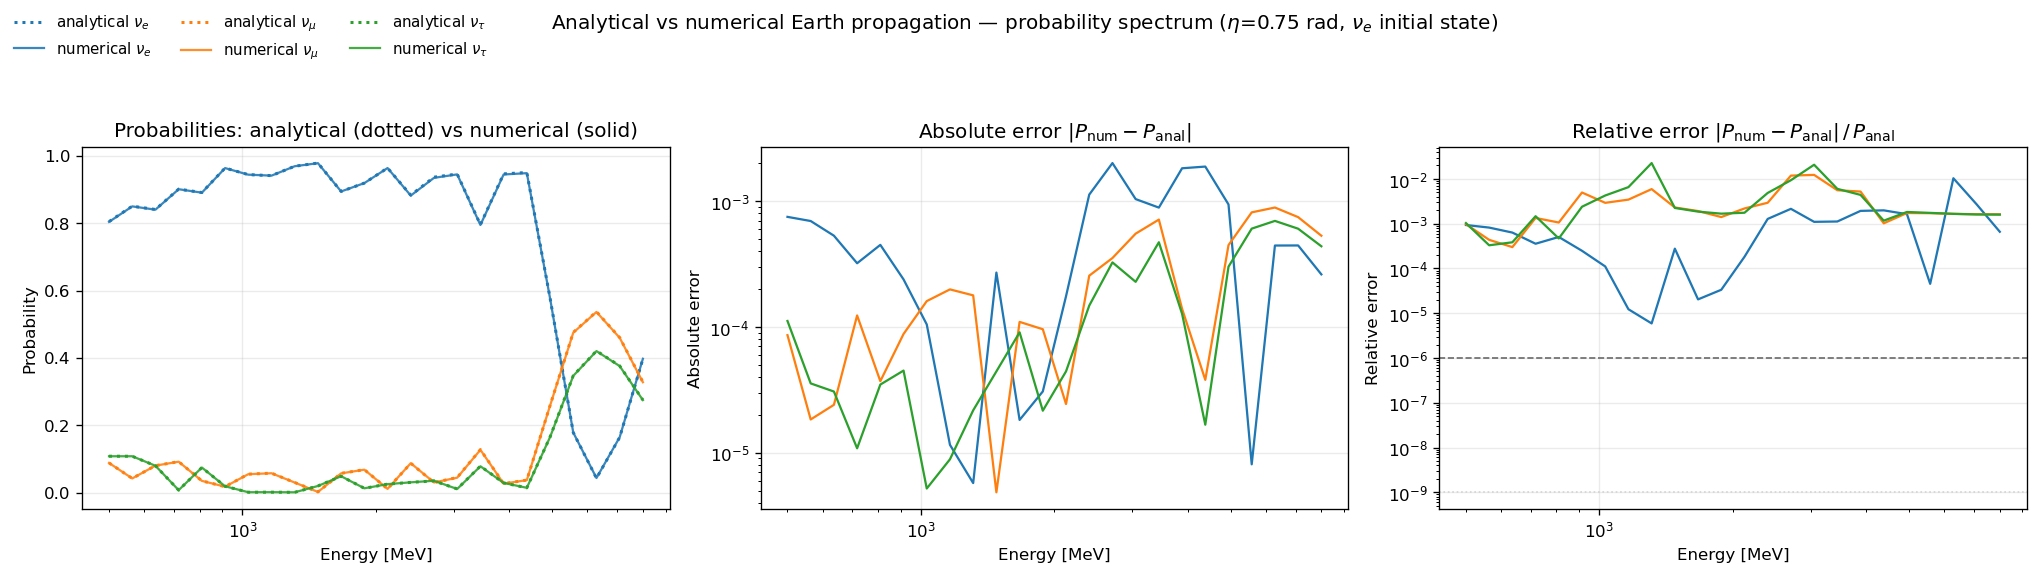

v:\output\validation\legacy\earth\validation_legacy3_earth_analytical_vs_numerical_spectrum.png


In [18]:
energies_np_32 = to_numpy(EARTH_METHOD_ENERGIES_MEV)
eta_val_32     = float(EARTH_METHOD_ETA_RAD.detach().cpu())

analytical_spectrum = torch.stack([
    tpeanuts_pearth(EARTH_METHOD_INITIAL_STATE, E, EARTH_METHOD_ETA_RAD,
                    massbasis=False, method="analytical")
    for E in EARTH_METHOD_ENERGIES_MEV
], dim=0)

numerical_spectrum = torch.stack([
    tpeanuts_pearth(EARTH_METHOD_INITIAL_STATE, E, EARTH_METHOD_ETA_RAD,
                    massbasis=False, method="numerical")
    for E in EARTH_METHOD_ENERGIES_MEV
], dim=0)

abs_delta_32, rel_delta_32 = abs_rel_delta(numerical_spectrum, analytical_spectrum)

value_floor = 1e-300
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)

for final_name, alpha in FLAVOUR_INDEX.items():
    label = FLAVOUR_LABELS[alpha]
    color = FLAVOUR_COLORS[alpha]
    axes[0].plot(energies_np_32, to_numpy(analytical_spectrum)[:, alpha],
                 color=color, linestyle=":", linewidth=1.8,  label=f"analytical {label}")
    axes[0].plot(energies_np_32, to_numpy(numerical_spectrum)[:, alpha],
                 color=color, linestyle="-",  linewidth=1.35, alpha=0.88, label=f"numerical {label}")
    axes[1].semilogy(energies_np_32, np.maximum(abs_delta_32[:, alpha], value_floor),
                     color=color, linewidth=1.35, label=label)
    axes[2].semilogy(energies_np_32, np.maximum(rel_delta_32[:, alpha], value_floor),
                     color=color, linewidth=1.35, label=label)

axes[0].set_title("Probabilities: analytical (dotted) vs numerical (solid)")
axes[1].set_title(r"Absolute error $|P_{\rm num} - P_{\rm anal}|$")
axes[2].set_title(r"Relative error $|P_{\rm num} - P_{\rm anal}|\,/\,P_{\rm anal}$")
axes[0].set_ylabel("Probability")
axes[1].set_ylabel("Absolute error")
axes[2].set_ylabel("Relative error")
add_tolerance_lines(axes[2])
for ax in axes:
    ax.set_xlabel("Energy [MeV]")
    ax.set_xscale("log")
    ax.grid(alpha=0.25)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="upper left", ncol=3, fontsize=9, frameon=False)
fig.suptitle(
    rf"Analytical vs numerical Earth propagation — probability spectrum"
    rf" ($\eta$={eta_val_32:.2f} rad, $\nu_e$ initial state)",
    y=1.03,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_and_show(
    "validation_legacy3_earth_analytical_vs_numerical_spectrum.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)


## 4. Comparison with Legacy Peanuts

### 4.1 Grid Comparison

TPeanuts' analytical Earth method is compared against the legacy `Pearth` reference at 48 parameter points: 4 nadir angles × 4 energies × 3 final flavours. Both implementations receive the same incoherent mass-basis initial state $\mathbf{w} = (0.20,\,0.30,\,0.50)$ and the same PREM density profile.

The Earth acts as a matter filter for atmospheric neutrinos: crossing the mantle (small $\eta$) produces a mild matter potential, while core-crossing trajectories ($\eta \lesssim 0.43\,\text{rad}$) can induce parametric resonance if the oscillation length and core diameter are commensurate. At energies near

$$E_\text{res} \approx \frac{\Delta m^2_{31}\cos 2\theta_{23}}{2\sqrt{2}\,G_F\,\langle n_e \rangle_\text{mantle}} \approx 7\text{–}10\,\text{GeV}$$

the $\nu_\mu \leftrightarrow \nu_\tau$ oscillation can be strongly enhanced by matter effects.

**Expected Results:** The analytical method reproduces the legacy Peanuts result to within a few parts per million (typical absolute difference $\lesssim 10^{-6}$), confirming that both the perturbative Earth pipeline and the PREM density profile are consistent between implementations.


In [19]:

earth_rows = []
for eta in EARTH_ETA_VALUES_RAD:
    for energy in EARTH_LEGACY_SAMPLE_ENERGIES_MEV:
        candidate = tpeanuts_pearth(MASS_WEIGHTS, energy, eta, massbasis=True, method="analytical")
        reference = legacy_pearth_eval(MASS_WEIGHTS_NP, energy, eta, massbasis=True, method="analytical")
        abs_delta, rel_delta = abs_rel_delta(candidate, reference)
        for final_name, alpha in FLAVOUR_INDEX.items():
            earth_rows.append({"medium": "earth", "observable": "earth_probability_state", "E_MeV": energy, "eta_rad": eta, "final_flavour": final_name, "candidate": to_numpy(candidate)[alpha], "reference": to_numpy(reference)[alpha], "abs_delta": abs_delta[alpha], "rel_delta": rel_delta[alpha]})
earth_probability_table = pd.DataFrame(earth_rows)
earth_probability_summary = summarize_validation(earth_probability_table, ["medium", "observable", "eta_rad"])
display(earth_probability_summary)


,medium,observable,eta_rad,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
1,earth,earth_probability_state,0.75,12,1.823979e-10,2.414610e-11,5.180948e-11,5.372418e-10,6.412469e-11,1.561537e-10,0.246757,0.338462
0,earth,earth_probability_state,0.35,12,7.131085e-11,2.729766e-11,3.177684e-11,2.490566e-10,8.888454e-11,9.775773e-11,0.234843,0.348397
2,earth,earth_probability_state,1.20,12,2.206457e-11,1.178713e-11,1.131302e-11,7.618634e-11,3.279054e-11,3.462679e-11,0.263306,0.344855
3,earth,earth_probability_state,2.40,12,5.551115e-17,0.000000e+00,1.850372e-17,1.374234e-16,0.000000e+00,4.580779e-17,0.236321,0.359736


### 4.2 Nadir Angle Scan

A continuous scan of the nadir angle $\eta \in [0.05, 1.50]\,\text{rad}$ at fixed energy $E = 1\,\text{GeV}$ visualises the full nadir-angle dependence of the Earth probability for the configured mass-weight input state. The three-panel format shows absolute probabilities, absolute difference, and relative difference vs $\eta$.

**Expected Results:** Sharp features near $\eta \approx 0.43\,\text{rad}$ (core-mantle boundary) and smooth behaviour in the mantle region. The relative difference should remain below the 1 ppm line across the full scan, validating the density-profile parameterisation and the trajectory geometry in both codes.

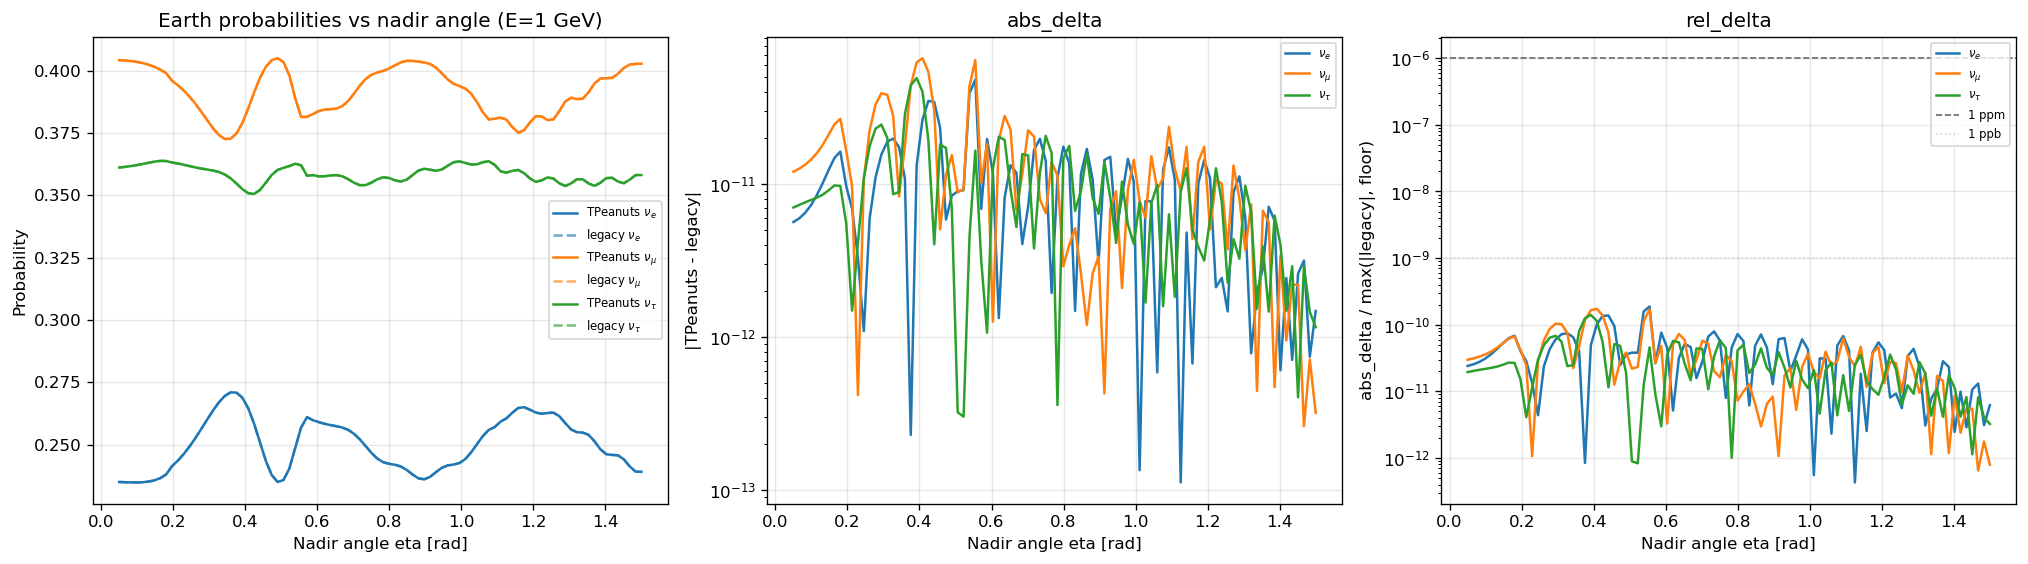

v:\output\validation\legacy\earth\validation_legacy3_earth_probability_vs_eta.png


In [20]:

P_t_eta = tpeanuts_pearth(MASS_WEIGHTS, EARTH_PLOT_ENERGY_MEV, EARTH_PLOT_ETA_GRID, massbasis=True, method="analytical")
P_l_eta = np.stack([legacy_pearth_eval(MASS_WEIGHTS_NP, float(EARTH_PLOT_ENERGY_MEV), float(eta), massbasis=True, method="analytical") for eta in to_numpy(EARTH_PLOT_ETA_GRID)])
plot_tripanel(EARTH_PLOT_ETA_GRID, P_t_eta, P_l_eta, title="Earth probabilities vs nadir angle (E=1 GeV)", xlabel="Nadir angle eta [rad]", filename="validation_legacy3_earth_probability_vs_eta.png", output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS, quantity="probability")


## 5. Precision Mode Diagnostic

This diagnostic compares the full-precision default and the legacy-precision compatibility mode against the legacy Peanuts Earth reference over the configured energy grid at the fixed diagnostic nadir angle. The panels show probability values, absolute differences, and relative differences.

,mode,eta_rad,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,full_precision,0.75,72,1.142633e-05,1.445136e-06,2.015156e-06,3.337676e-05,4.096300e-06,6.124255e-06,0.222628,0.355178
1,legacy_precision,0.75,72,1.801074e-10,1.560006e-11,2.685737e-11,5.464339e-10,5.063528e-11,8.376476e-11,0.222628,0.355178


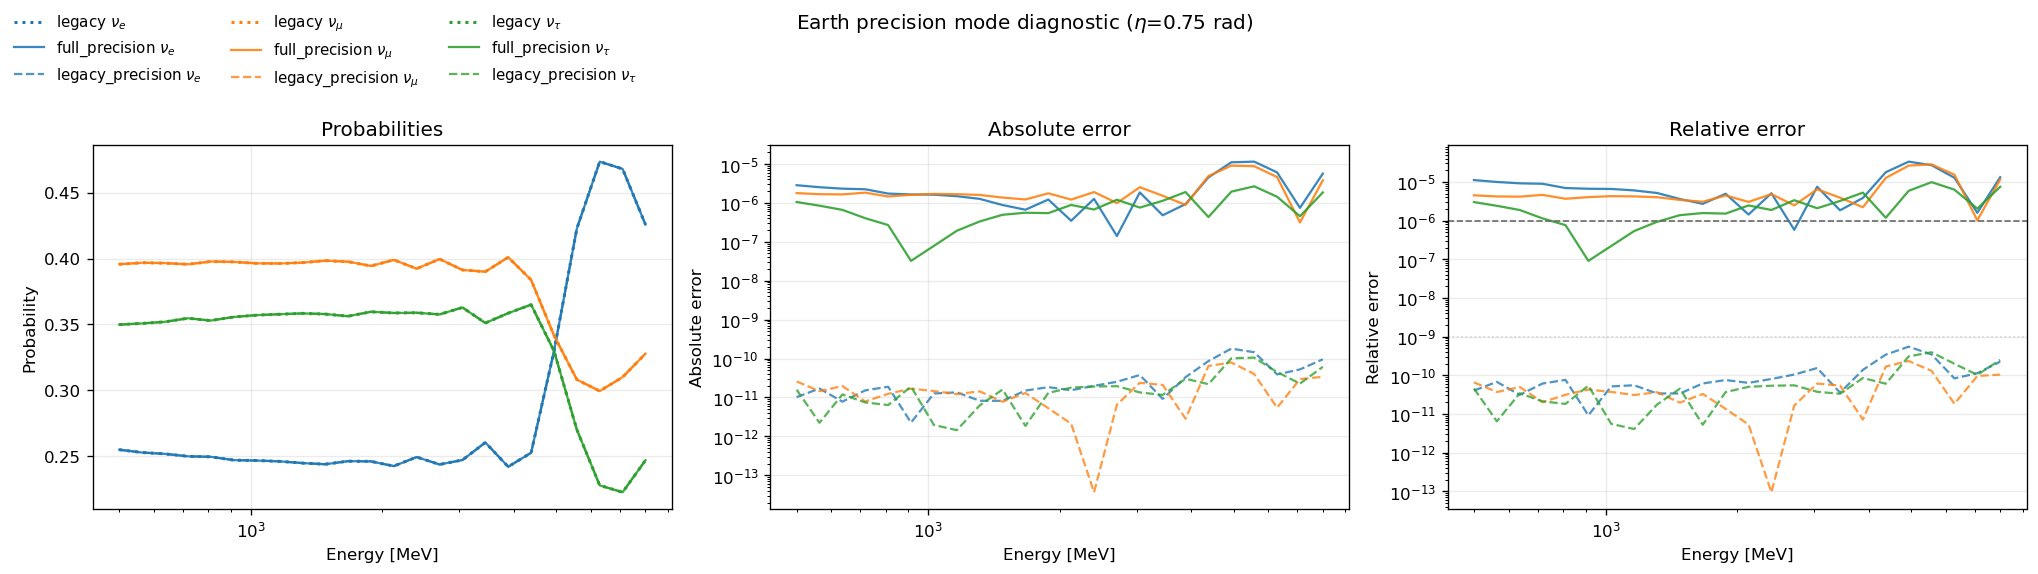

v:\output\validation\legacy\earth\validation_legacy3_earth_precision_modes_energy_scan.png


In [21]:
precision_modes = [("full_precision", False), ("legacy_precision", True)]
precision_energy_np = to_numpy(EARTH_METHOD_ENERGIES_MEV)
precision_eta_rad = float(EARTH_METHOD_ETA_RAD.detach().cpu())
precision_reference = np.stack([
    legacy_pearth_eval(MASS_WEIGHTS_NP, float(energy), precision_eta_rad, massbasis=True, method="analytical")
    for energy in precision_energy_np
])

precision_rows = []
precision_scan_by_mode = {}
for mode_name, mode_flag in precision_modes:
    candidate_scan = torch.stack([
        tpeanuts_pearth(MASS_WEIGHTS, energy, EARTH_METHOD_ETA_RAD, massbasis=True, method="analytical", legacy_precision=mode_flag)
        for energy in EARTH_METHOD_ENERGIES_MEV
    ], dim=0)
    precision_scan_by_mode[mode_name] = candidate_scan
    abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
    candidate_np = to_numpy(candidate_scan)
    for i, energy in enumerate(precision_energy_np):
        for final_name, alpha in FLAVOUR_INDEX.items():
            precision_rows.append(
                {
                    "medium": "earth",
                    "observable": "pearth_precision_mode",
                    "E_MeV": energy,
                    "eta_rad": precision_eta_rad,
                    "mode": mode_name,
                    "final_flavour": final_name,
                    "candidate": candidate_np[i, alpha],
                    "reference": precision_reference[i, alpha],
                    "abs_delta": abs_delta[i, alpha],
                    "rel_delta": rel_delta[i, alpha],
                    "legacy_precision": mode_flag,
                }
            )
precision_mode_table = pd.DataFrame(precision_rows)
precision_mode_summary = summarize_validation(precision_mode_table, ["mode", "eta_rad"])
display(precision_mode_summary)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.6), sharex=True)
mode_styles = {"full_precision": "-", "legacy_precision": "--"}
mode_alphas = {"full_precision": 0.88, "legacy_precision": 0.78}
value_floor = 1.0e-300

for final_name, alpha in FLAVOUR_INDEX.items():
    label = FLAVOUR_LABELS[alpha]
    color = FLAVOUR_COLORS[alpha]
    axes[0].plot(precision_energy_np, precision_reference[:, alpha], color=color, linestyle=":", linewidth=1.8, label=f"legacy {label}")
    for mode_name, _ in precision_modes:
        candidate_scan = precision_scan_by_mode[mode_name]
        candidate_np = to_numpy(candidate_scan)
        abs_delta, rel_delta = abs_rel_delta(candidate_scan, precision_reference)
        axes[0].plot(precision_energy_np, candidate_np[:, alpha], color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[1].semilogy(precision_energy_np, np.maximum(abs_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")
        axes[2].semilogy(precision_energy_np, np.maximum(rel_delta[:, alpha], value_floor), color=color, linestyle=mode_styles[mode_name], alpha=mode_alphas[mode_name], linewidth=1.35, label=f"{mode_name} {label}")

axes[0].set_title("Probabilities")
axes[1].set_title("Absolute error")
axes[2].set_title("Relative error")
axes[0].set_ylabel("Probability")
axes[1].set_ylabel("Absolute error")
axes[2].set_ylabel("Relative error")
add_tolerance_lines(axes[2])
for ax in axes:
    ax.set_xlabel("Energy [MeV]")
    ax.set_xscale("log")
    ax.grid(alpha=0.25)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", ncol=3, fontsize=9, frameon=False)
fig.suptitle(rf"Earth precision mode diagnostic ($\eta$={precision_eta_rad:.2f} rad)", y=1.03)
fig.tight_layout(rect=(0, 0, 1, 0.94))
save_and_show(
    "validation_legacy3_earth_precision_modes_energy_scan.png",
    fig,
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
)


## 6. Earth Flux Propagation

This section validates the incoherent flux propagation obtained from the Earth probability matrix. A synthetic mass-eigenstate flux $\Phi_i(E)$ is defined over the same diagnostic energy grid,

$$\Phi_i(E) = N_i \left(\frac{E}{E_0}\right)^{-\gamma_i} \exp\!\left(-\frac{E}{E_{c,i}}\right),$$

and propagated through the Earth at the fixed diagnostic nadir angle. The propagated flavour flux is

$$\Phi_\alpha^\oplus(E,\eta) = \sum_i P(i \to \nu_\alpha; E, \eta)\,\Phi_i(E).$$

This tests the matrix-vector contraction used for incoherent fluxes after the individual Earth probability elements have been validated.

**Expected Results:**
- The flux residuals should follow the same precision level as the underlying Earth probability matrix at the selected nadir angle.
- Relative differences can grow mildly where a propagated flux component is strongly suppressed; the summary therefore reports both absolute and relative residuals.


,medium,observable,eta_rad,rows,max_abs_delta,median_abs_delta,mean_abs_delta,max_rel_delta,median_rel_delta,mean_rel_delta,min_reference,median_reference
0,earth,flux,0.75,72,2.004413e-08,4.553766e-10,1.788081e-09,2.585791e-10,2.927132e-11,4.274067e-11,0.861204,18.393861


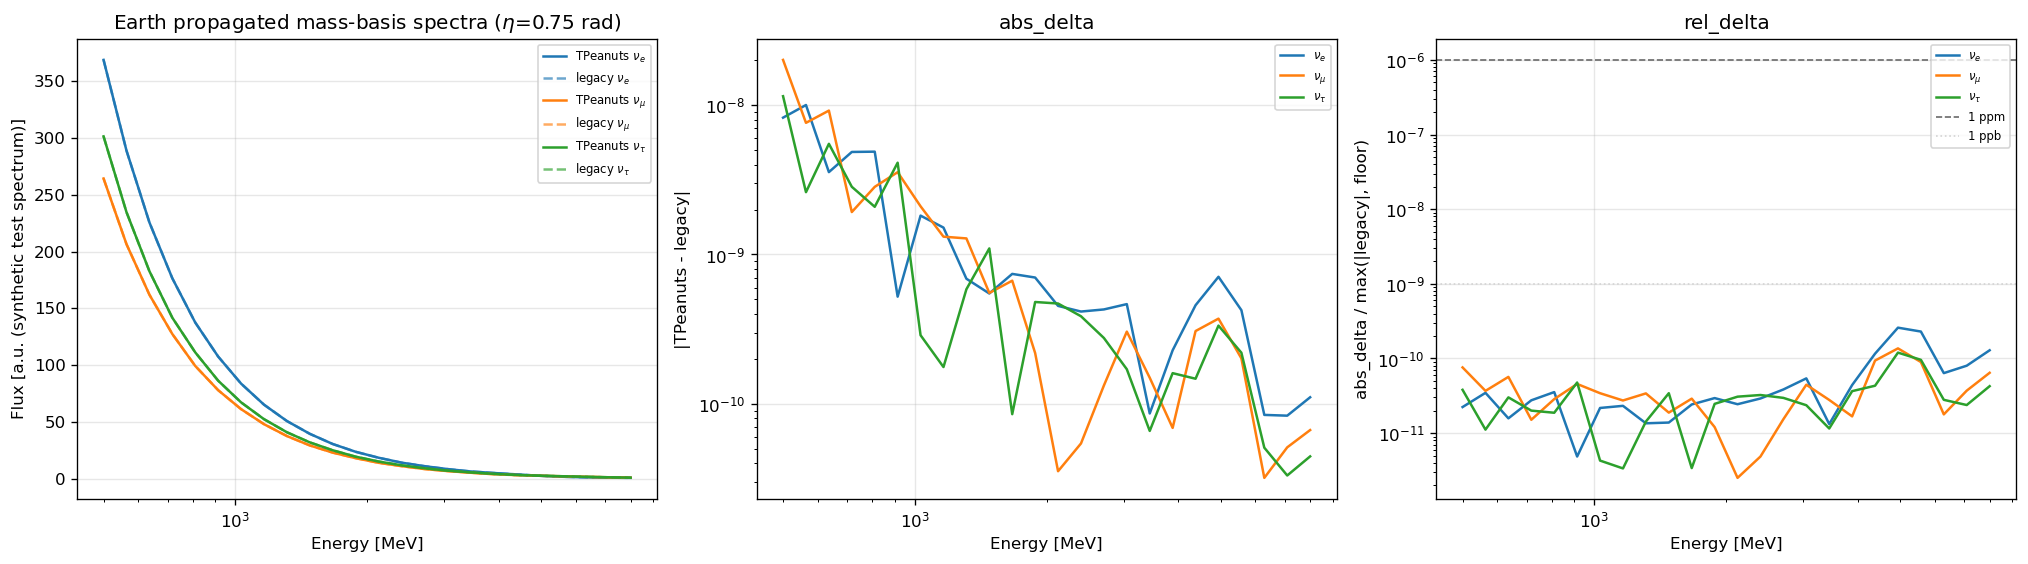

v:\output\validation\legacy\earth\validation_legacy3_earth_flux_scan.png


In [22]:
def synthetic_mass_flux(E_MeV: torch.Tensor) -> torch.Tensor:
    x = E_MeV / 1000.0
    return torch.stack([
        1.00e2 * x.pow(-2.10) * torch.exp(-E_MeV / 5.0e4),
        8.00e1 * x.pow(-2.00) * torch.exp(-E_MeV / 6.0e4),
        5.00e1 * x.pow(-1.95) * torch.exp(-E_MeV / 7.0e4),
    ], dim=-1)


def earth_probability_matrix_t(energies_MeV, eta_rad):
    basis = torch.eye(3, dtype=DTYPE, device=DEVICE)
    matrices = []
    for energy in energies_MeV:
        matrices.append(torch.stack([
            tpeanuts_pearth(basis[i], energy, eta_rad, massbasis=True, method="analytical")
            for i in range(3)
        ], dim=-1))
    return torch.stack(matrices, dim=0)


def earth_probability_matrix_l(energies_MeV, eta_rad):
    matrix = np.empty((len(to_numpy(energies_MeV)), 3, 3), dtype=float)
    basis = np.eye(3)
    for j, energy in enumerate(to_numpy(energies_MeV)):
        for i in range(3):
            matrix[j, :, i] = legacy_pearth_eval(basis[i], float(energy), float(eta_rad), massbasis=True, method="analytical")
    return matrix


earth_flux_eta_rad = precision_eta_rad
earth_flux_in = synthetic_mass_flux(EARTH_METHOD_ENERGIES_MEV)
P_t_flux_matrix = earth_probability_matrix_t(EARTH_METHOD_ENERGIES_MEV, EARTH_METHOD_ETA_RAD)
P_l_flux_matrix = earth_probability_matrix_l(EARTH_METHOD_ENERGIES_MEV, earth_flux_eta_rad)
earth_flux_t = probability_incoherent(P_t_flux_matrix, earth_flux_in)
earth_flux_l = np.einsum("eba,ea->eb", P_l_flux_matrix, to_numpy(earth_flux_in))
abs_flux, rel_flux = abs_rel_delta(earth_flux_t, earth_flux_l)

flux_rows = []
for j, energy in enumerate(to_numpy(EARTH_METHOD_ENERGIES_MEV)):
    for final_name, alpha in FLAVOUR_INDEX.items():
        flux_rows.append({
            "medium": "earth",
            "observable": "flux",
            "E_MeV": energy,
            "eta_rad": earth_flux_eta_rad,
            "final_flavour": final_name,
            "candidate": to_numpy(earth_flux_t)[j, alpha],
            "reference": earth_flux_l[j, alpha],
            "abs_delta": abs_flux[j, alpha],
            "rel_delta": rel_flux[j, alpha],
        })

earth_flux_table = pd.DataFrame(flux_rows)
display(summarize_validation(earth_flux_table, ["medium", "observable", "eta_rad"]))
plot_tripanel(
    EARTH_METHOD_ENERGIES_MEV,
    earth_flux_t,
    earth_flux_l,
    title=rf"Earth propagated mass-basis spectra ($\eta$={earth_flux_eta_rad:.2f} rad)",
    xlabel="Energy [MeV]",
    filename="validation_legacy3_earth_flux_scan.png",
    output_dir=OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    xscale="log",
    quantity="flux",
    flux_units="a.u. (synthetic test spectrum)",
)


## 7. Export Results

Six CSV files are written to `VALIDATION_ROOT/earth/` for aggregation by the summary notebook:

- `validation_legacy3_earth_tpeanuts_method.csv` - internal analytical vs numerical comparison (24 energies x 3 flavours).
- `validation_legacy3_earth_probability.csv` - full TPeanuts vs legacy grid (4 nadir x 4 energy x 3 flavour = 48 rows).
- `validation_legacy3_earth_probability_summary.csv` - max/median/mean delta grouped by nadir angle.
- `validation_legacy3_earth_precision_modes.csv` - full energy-grid comparison between full precision and legacy precision.
- `validation_legacy3_earth_precision_modes_summary.csv` - grouped summary of the precision-mode deltas.
- `validation_legacy3_earth_flux.csv` - flux-propagation comparison across the diagnostic energy grid.

In [23]:

#earth_method_table.to_csv(OUTPUT_DIR / "validation_legacy3_earth_tpeanuts_method.csv", index=False)
earth_probability_table.to_csv(OUTPUT_DIR / "validation_legacy3_earth_probability.csv", index=False)
earth_probability_summary.to_csv(OUTPUT_DIR / "validation_legacy3_earth_probability_summary.csv", index=False)
#precision_mode_table.to_csv(OUTPUT_DIR / "validation_legacy3_earth_precision_modes.csv", index=False)
#precision_mode_summary.to_csv(OUTPUT_DIR / "validation_legacy3_earth_precision_modes_summary.csv", index=False)
earth_flux_table.to_csv(OUTPUT_DIR / "validation_legacy3_earth_flux.csv", index=False)
print(OUTPUT_DIR)


v:\output\validation\legacy\earth


## 8. Summary

The final table collects the analytical-vs-numerical Earth check, the TPeanuts-vs-legacy grid comparison, the explicit precision-mode diagnostic, and the flux-propagation check.

In [24]:
summary_tables = [
    ("analytical vs numerical", earth_method_table),
    ("legacy grid", earth_probability_table),
    ("precision modes", precision_mode_table),
    ("earth flux", earth_flux_table),
]
summary_rows = []
for label, table in summary_tables:
    summary_rows.append({
        "check": label,
        "rows": len(table),
        "max_abs_delta": table["abs_delta"].max(),
        "max_rel_delta": table["rel_delta"].max(),
        "median_rel_delta": table["rel_delta"].median(),
        "status": status_from_rel(table["rel_delta"].max()),
    })
validation_summary = pd.DataFrame(summary_rows)
display(validation_summary)
print(f"Earth validation sections used LEGACY_PRECISION={LEGACY_PRECISION}; Section 5 intentionally compares both precision modes.")

,check,rows,max_abs_delta,max_rel_delta,median_rel_delta,status
0,analytical vs numerical,72,2.011576e-03,2.258346e-02,1.644464e-03,CHECK
1,legacy grid,48,1.823979e-10,5.372418e-10,4.351737e-11,PASS < ppb
2,precision modes,144,1.142633e-05,3.337676e-05,4.566775e-08,CHECK < 1e-3
3,earth flux,72,2.004413e-08,2.585791e-10,2.927132e-11,PASS < ppb


Earth validation sections used LEGACY_PRECISION=True; Section 5 intentionally compares both precision modes.
